In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
os.chdir(r"G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting")
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [5]:
df = pd.read_csv(r'airline_passengers.csv', index_col = 'Month', parse_dates = True)

In [6]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [8]:
df.isna().sum()

Passengers    0
dtype: int64

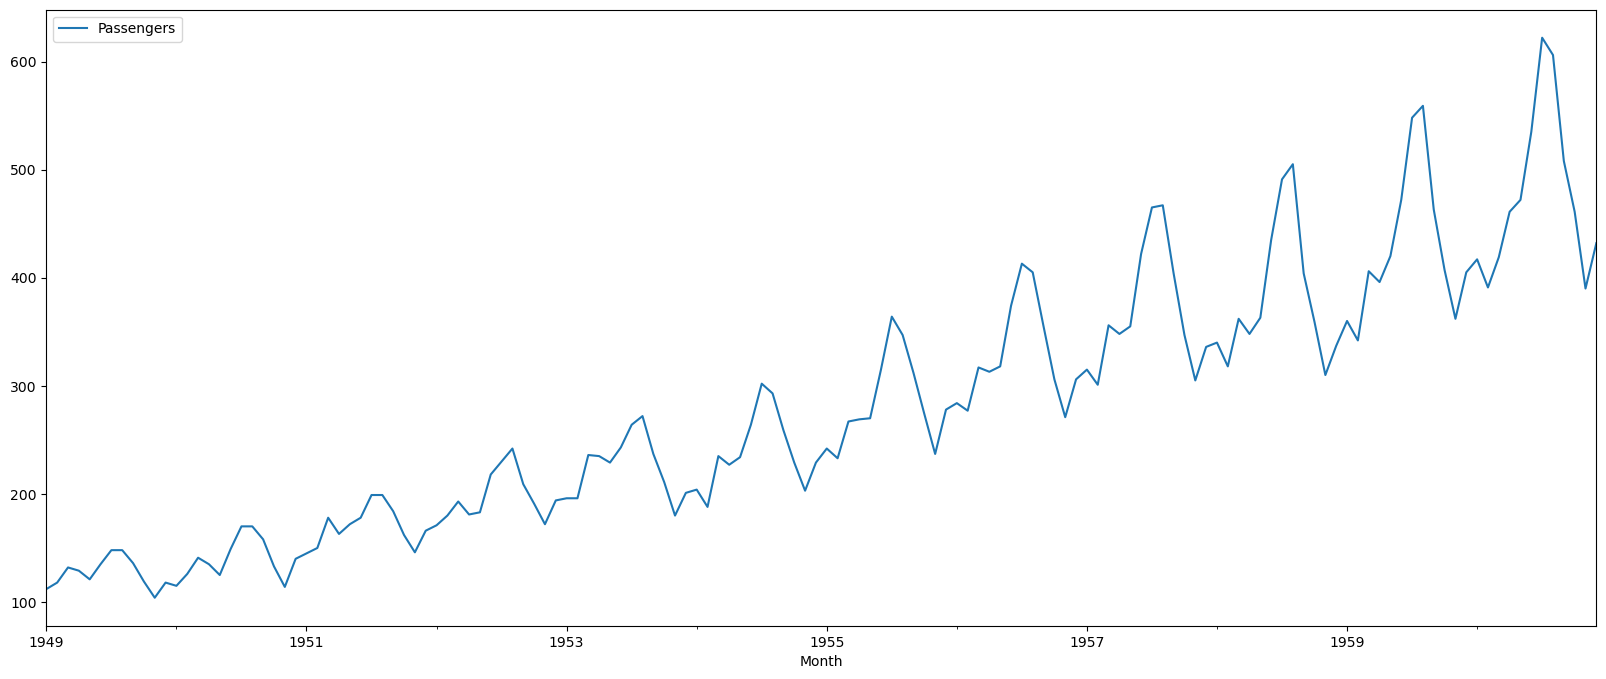

In [10]:
df.plot(figsize = (20,8));

array([[<Axes: title={'center': 'Passengers'}>]], dtype=object)

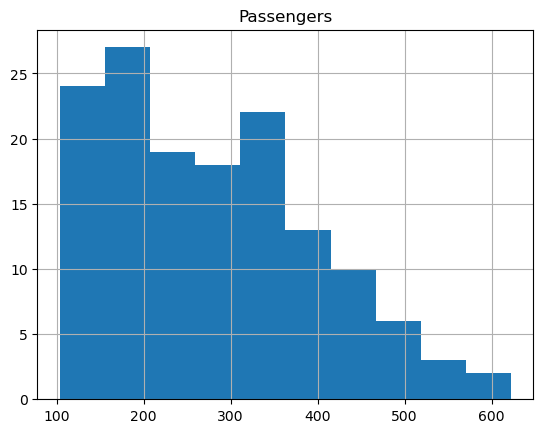

In [11]:
df.hist()

In [12]:
alpha = 0.2

In [14]:
df['EWMA'] = df['Passengers'].ewm(alpha = alpha, adjust = False).mean()
#adjust = true assumes data is finite and adjusts the wights so that the sum of weights is always 1 - this is the default in pandas
# adjust = false assumes data series is infinite or already reached a steady state.

In [16]:
type(df['Passengers'].ewm(alpha = alpha, adjust = False))

pandas.core.window.ewm.ExponentialMovingWindow

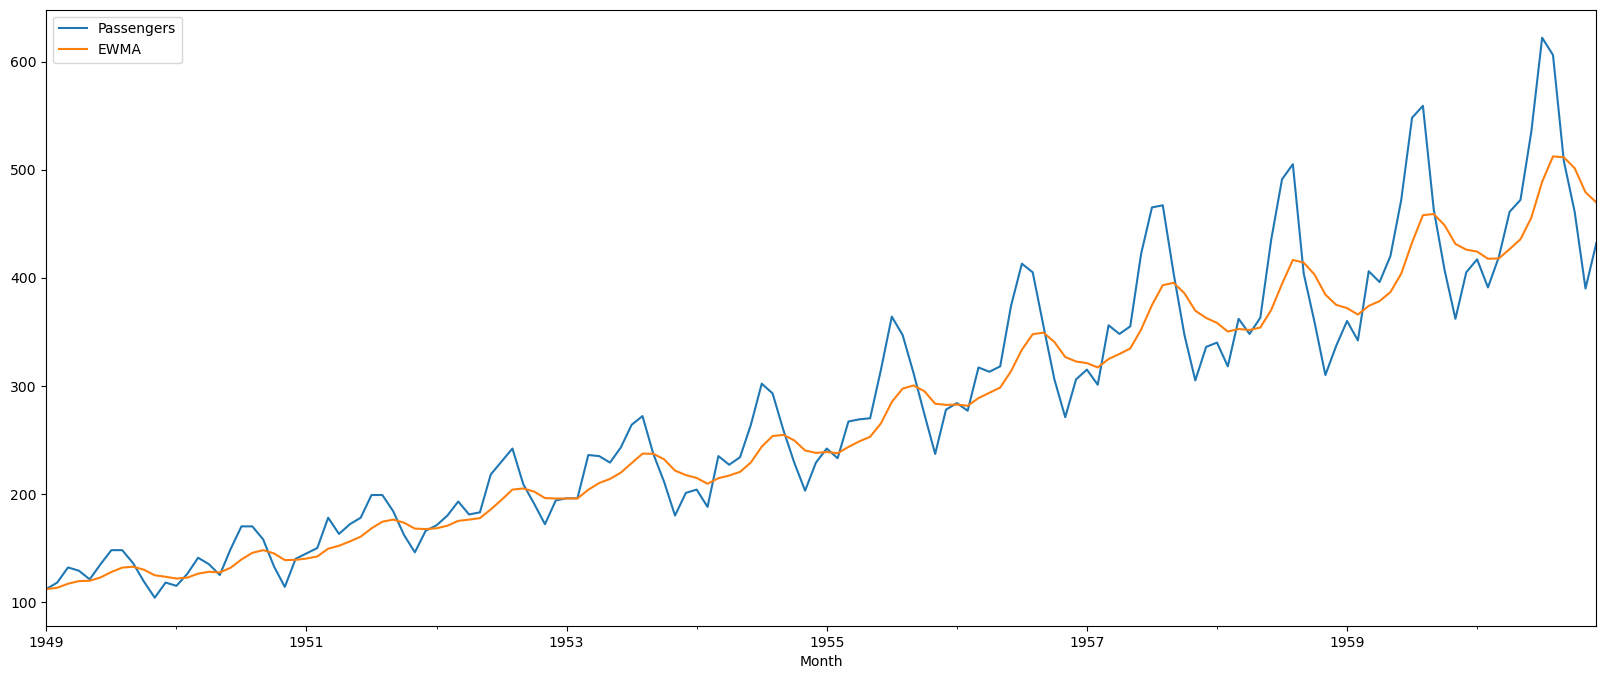

In [19]:
df.plot(figsize = (20,8));

In [20]:
# CREATING THIS MANUALLY
manual_ewma = []
for x in df['Passengers'].to_numpy():
    if len(manual_ewma)>0:
        xhat = alpha * x + (1-alpha) * manual_ewma[-1]
    else:
       xhat = x
    manual_ewma.append(xhat)
df['Manual'] = manual_ewma

In [21]:
df.head()

,Passengers,EWMA,Manual
Month,,,
1949-01-01,112,112.0000,112.0000
1949-02-01,118,113.2000,113.2000
1949-03-01,132,116.9600,116.9600
1949-04-01,129,119.3680,119.3680
1949-05-01,121,119.6944,119.6944


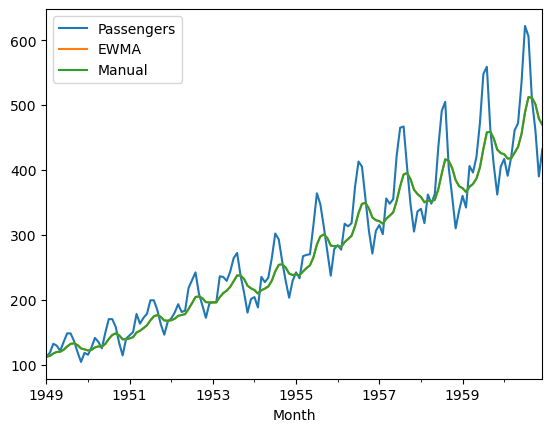

In [22]:
df.plot();

In [23]:
df.drop('Manual', axis=1, inplace = True)

In [24]:
df.head()

,Passengers,EWMA
Month,,
1949-01-01,112,112.0000
1949-02-01,118,113.2000
1949-03-01,132,116.9600
1949-04-01,129,119.3680
1949-05-01,121,119.6944
